In [257]:
cd ..

e:\


In [258]:
import sys
import os

# Add project root (change if needed)
project_root = r"E:\notebooks\MultimodalTweetsClassification"
sys.path.append(project_root)

from exp.Required_Modules_And_Packages import *
from sample_data.Data_Reading_And_Preprocessing import *


In [259]:
#ensuring that any edits to libraries you make are reloaded here automatically
#to ensuere charts or images displayed are shown in this notebook
%reload_ext autoreload
%autoreload 2
%matplotlib inline 

In [260]:
from exp.Required_Modules_And_Packages import *
from sample_data.Data_Reading_And_Preprocessing import *
from exp.Required_Integration_Functionalities_For_Transformer_To_Fastai import *
from exp.Required_Functionalities_To_Handal_Multimodal_Dataset import *
from exp.Multimodal_Model_With_Intermediate_Or_EmbraceNet_Fusion import *


In [261]:
path = Path('/notebooks/MultimodalTweetsClassification')
# path.ls()

In [262]:
path_img = path/'data_image'

In [267]:
data_info_text,test_data_info_text = get_dataframe(*get_tsv_data_files('Informativeness_task_tsv_files'),path)

reading data and preprocessing it.....
done!!


In [268]:
print(f"shape of data: {data_info_text.shape}\n")
print(f"train set: {data_info_text['is_valid'].value_counts()[0]}")
print(f"valid set: {data_info_text['is_valid'].value_counts()[1]}")      
print("="*50)
print(f"shape of test data: {test_data_info_text.shape}\n")

shape of data: (914, 10)

train set: 804
valid set: 110
shape of test data: (107, 9)



In [269]:
# # Create smaller sample while keeping original variable names
# from sklearn.model_selection import train_test_split
# import pandas as pd

# # Define sample size (adjust as needed)
# SAMPLE_SIZE = 1000  # Total samples you want
# TEST_SAMPLE_SIZE = 200  # Test samples you want

# # Sample training data while maintaining the train/valid split ratio
# train_data = data_info_text[data_info_text['is_valid'] == 0]
# valid_data = data_info_text[data_info_text['is_valid'] == 1]

# # Calculate proportional sample sizes
# train_ratio = len(train_data) / len(data_info_text)
# valid_ratio = len(valid_data) / len(data_info_text)

# train_sample_size = int(SAMPLE_SIZE * train_ratio)
# valid_sample_size = int(SAMPLE_SIZE * valid_ratio)

# # Sample from each subset
# train_sample = train_data.sample(n=min(train_sample_size, len(train_data)), random_state=42)
# valid_sample = valid_data.sample(n=min(valid_sample_size, len(valid_data)), random_state=42)

# # Replace original data with sampled data (keeping same variable names)
# data_info_text = pd.concat([train_sample, valid_sample], ignore_index=True)
# test_data_info_text = test_data_info_text.sample(
#     n=min(TEST_SAMPLE_SIZE, len(test_data_info_text)), 
#     random_state=42
# )

# # Your original verification code - no changes needed
# print(f"shape of data: {data_info_text.shape}\n")
# print(f"train set: {data_info_text['is_valid'].value_counts()[0]}")
# print(f"valid set: {data_info_text['is_valid'].value_counts()[1]}")      
# print("="*50)
# print(f"shape of test data: {test_data_info_text.shape}\n")

In [270]:
data_info_text.head()

,event_name,tweet_id,image_id,tweet_text,image,label,label_text,label_image,label_text_image,is_valid
0,srilanka_floods,8.700000e+17,869972354004393987_1,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
1,srilanka_floods,8.700000e+17,869972354004393987_2,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
2,srilanka_floods,8.700000e+17,869972354004393987_3,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
3,srilanka_floods,8.700000e+17,869977622377320448_0,sentinel was used to map the flood in matara s...,data_image/srilanka_floods/31_5_2017/869977622...,not_informative,informative,not_informative,Negative,False
4,srilanka_floods,8.700000e+17,869977622377320448_1,sentinel was used to map the flood in matara s...,data_image/srilanka_floods/31_5_2017/869977622...,informative,informative,not_informative,Negative,False


In [271]:
from transformers import BertTokenizer, BertForSequenceClassification
from exp.Required_Integration_Functionalities_For_Transformer_To_Fastai import (
    TransformersBaseTokenizer, TransformersVocab, CustomTransformerModel
)
from exp.Required_Modules_And_Packages import *
from exp.Data_Reading_And_Preprocessing import *

In [272]:
num_labels = len(data_info_text['label_text'].unique())
model_path = r"e:\notebooks\MultimodalTweetsClassification\bert_model"
# hf_tokenizer = BertTokenizer.from_pretrained(model_path)
# hf_model = BertForSequenceClassification.from_pretrained(model_path, num_labels=num_labels)


from transformers import BertForSequenceClassification
import torch.nn as nn

# Load with original shape (8 labels)
hf_model = BertForSequenceClassification.from_pretrained(model_path, num_labels=8)

# Replace classifier for 2 labels
hf_model.classifier = nn.Linear(hf_model.config.hidden_size, num_labels)
hf_model.config.num_labels = num_labels


In [273]:
fastai_tokenizer = TransformersBaseTokenizer(hf_tokenizer)
fastai_vocab = TransformersVocab(hf_tokenizer)

In [274]:
from fastai.text import Tokenizer, TokenizeProcessor, NumericalizeProcessor

fastai_tokenizer = Tokenizer(
    tok_func=TransformersBaseTokenizer(hf_tokenizer, model_type='bert'),
    pre_rules=[], post_rules=[], n_cpus=1
)
fastai_vocab = TransformersVocab(hf_tokenizer)

processor = [TokenizeProcessor(tokenizer=fastai_tokenizer), NumericalizeProcessor(vocab=fastai_vocab)]



def get_text_data(dataframe, path, pad_first=True, pad_idx=1, batch_size=64, processor=None, vocab=None, num_workers=0):
    text_data = (TextList.from_df(dataframe, path, cols='tweet_text', processor=processor, vocab=vocab)
                 .split_from_df(col='is_valid')
                 .label_from_df(cols='label_text')
                 .databunch(bs=batch_size, pad_first=pad_first, pad_idx=pad_idx, num_workers=num_workers))
    return text_data

# function to create databunch object of test text data using test split

def get_test_text_data(dataframe, path, pad_first=True, pad_idx=1, batch_size=64, processor=None, vocab=None, num_workers=0):
    test_text_data = (TextList.from_df(dataframe, path, cols='tweet_text', processor=processor, vocab=vocab)
                      .split_none()
                      .label_from_df(cols='label_text')
                      .databunch(bs=batch_size, pad_first=pad_first, pad_idx=pad_idx, num_workers=num_workers))
    return test_text_data


data_clas = get_text_data(
    data_info_text,
    path,
    processor=processor,
    vocab=fastai_vocab
)
test_data_clas = get_test_text_data(
    test_data_info_text,
    path,
    processor=processor,
    vocab=fastai_vocab
)
data_clas.add_test(test_data_clas.train_ds)
data_clas.test_ds.y = test_data_clas.train_ds.y

In [275]:
pad_idx = hf_tokenizer.pad_token_id
model = CustomTransformerModel(pad_idx, hf_model)

In [276]:
from torch.nn import CrossEntropyLoss

learn_clas = Learner(
    data_clas,
    model,
    loss_func=CrossEntropyLoss(),
    metrics=[accuracy, Precision1(average='macro'), Precision1(average='weighted')],
    callback_fns=[ShowGraph]
)

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.
Min numerical gradient: 9.12E-05
Min loss divided by 10: 5.75E-05


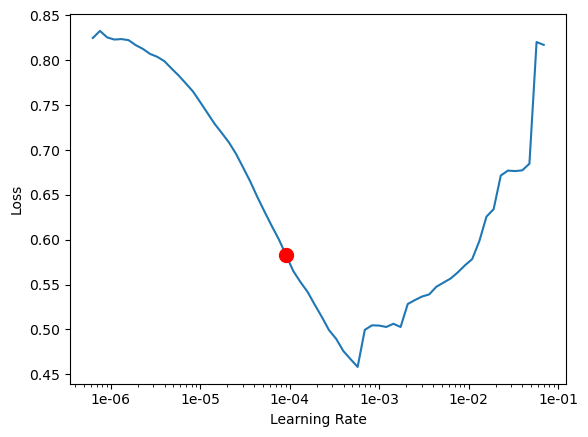

In [277]:
learn_clas.lr_find()
learn_clas.recorder.plot(suggestion=True)

epoch,train_loss,valid_loss,accuracy,precision1,precision1,time
0,0.489421,0.276626,0.900000,0.895225,0.914324,01:27
1,0.288806,0.247111,0.927273,0.927183,0.927260,01:33
2,0.217010,0.218764,0.936364,0.930027,0.938476,01:27
3,0.162157,0.198572,0.945455,0.938776,0.952134,01:30


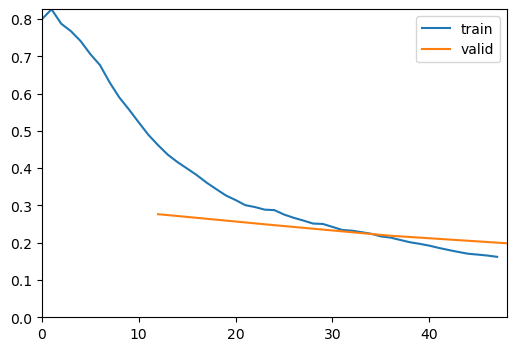

In [278]:
learn_clas.fit_one_cycle(4, 1e-4)

              precision    recall  f1-score   support

        INFO       0.88      1.00      0.93        43
  Non - Info       1.00      0.91      0.95        67

    accuracy                           0.95       110
   macro avg       0.94      0.96      0.94       110
weighted avg       0.95      0.95      0.95       110



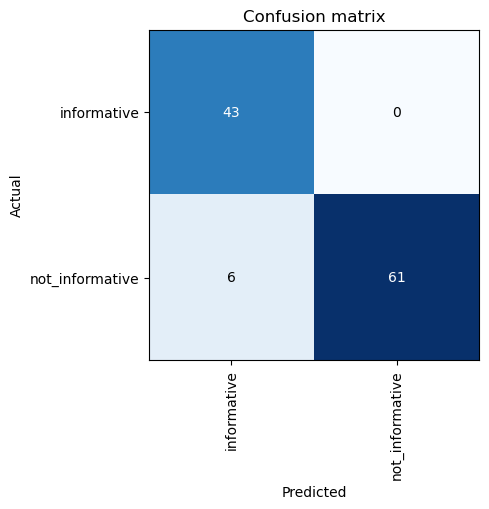

In [279]:
interp = ClassificationInterpretation.from_learner(learn_clas)
interp.plot_confusion_matrix(figsize=(5,5), dpi=100)

preds, y, losses = learn_clas.get_preds(ds_type=DatasetType.Valid, with_loss=True)
y_preds = preds.argmax(1)

target_names = [
    'INFO',
    'Non - Info',
]
print(classification_report(y, y_preds, target_names=target_names))